# 43.2 · Noise prediction and training

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain noise prediction and training using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[02 · Mathematics for Computer Vision](../../02-mathematics-for-computer-vision/README.md), [38 · Attention Mechanisms](../../38-attention-mechanisms/README.md), [42 · Generative Computer Vision](../../42-generative-computer-vision/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Diffusion models learn to reverse a gradual noising process. The forward process is prescribed, while a network learns a reverse-step ingredient such as noise prediction. Sampling repeats many learned denoising steps, making the noise schedule and parameterization essential.

## 2. Intuition

A noise-prediction network sees the noisy image and time index and predicts the injected noise. Mean squared error supplies a simple training objective. Time conditioning tells the network which noise level it is solving. The local model is a small MLP trained on 16×16 generated shapes.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 43
LESSON = 1
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon
$$

x0 is clean data, ε standard-normal noise, ᾱt cumulative signal retention and xt the noisy sample. With ᾱ=0.64, x0=1 and ε=0, xt=0.8. The two square-root factors control signal and noise variance.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
alpha_bar, clean, noise = 0.64, 1.0, 0.0
noisy = np.sqrt(alpha_bar) * clean + np.sqrt(1 - alpha_bar) * noise
assert np.isclose(noisy, 0.8)
print(noisy)

0.8


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The source samples random time indices, creates noisy inputs with known noise targets, optimizes an MSE objective and executes a reverse loop. Training and sampling use the same stored schedule.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def diffusion(lesson, seed, amount):
    _, history, clean, sample, alpha_bar = diffusion_train_sample(
        seed, updates=40 if lesson == 0 else 70
    )
    return Result(
        "43 · Forward noise and learned reverse diffusion",
        {
            "Training shapes in [-1,1]": torch.cat(list(clean[:, 0]), 1).numpy(),
            "Generated short-run samples": torch.cat(list(sample[:, 0]), 1).numpy(),
        },
        curves={"Noise prediction MSE": history, "Signal retention alpha-bar": alpha_bar.numpy()},
        metrics={"updates": len(history), "diffusion_steps": 32},
        notes="Fixed-variance DDPM-style teaching sampler; short CPU runs often make poor samples. No pretrained diffusion weights or quality metric is implied.",
    )

{
  "updates": 70,
  "diffusion_steps": 32
}
Fixed-variance DDPM-style teaching sampler; short CPU runs often make poor samples. No pretrained diffusion weights or quality metric is implied.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/models.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.models import diffusion_train_sample

display(Code(inspect.getsource(diffusion_train_sample), language="python"))

def diffusion_train_sample(seed=42, updates=80):
    configure(seed)
    x, _, _ = shape_data(64, size=16, seed=seed)
    x = x * 2 - 1
    model = NoisePredictor()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    beta = torch.linspace(0.0001, 0.2, 32)
    alpha = 1 - beta
    alpha_bar = alpha.cumprod(0)
    history = []
    for _ in range(updates):
        indices = torch.randint(0, len(x), (16,))
        clean = x[indices]
        t = torch.randint(0, 32, (len(clean),))
        noise = torch.randn_like(clean)
        a = alpha_bar[t, None, None, None]
        noisy = a.sqrt() * clean + (1 - a).sqrt() * noise
        loss = F.mse_loss(model(noisy, t), noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        history.append(float(loss.detach()))
    sample = torch.randn(4, 1, 16, 16)
    with torch.no_grad():
        for index in range(31, -1, -1):
            noise = model(sample, torch.full((4,), index))
            sample = (sample - beta[index] / torch.sqrt(1 - alpha_bar[index]) * noise) / torch.sqrt(
                alpha[index]
            )
            if index:
                sample += torch.sqrt(beta[index]) * torch.randn_like(sample)
    return model, history, x[:4], sample.clamp(-1, 1), alpha_bar

## 8. Experiment

Plot signal retention across steps and compare samples after different training budgets. Check that the final forward state is close to the assumed starting distribution.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "updates": 70,
    "diffusion_steps": 32
  },
  "second_seed": {
    "updates": 70,
    "diffusion_steps": 32
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

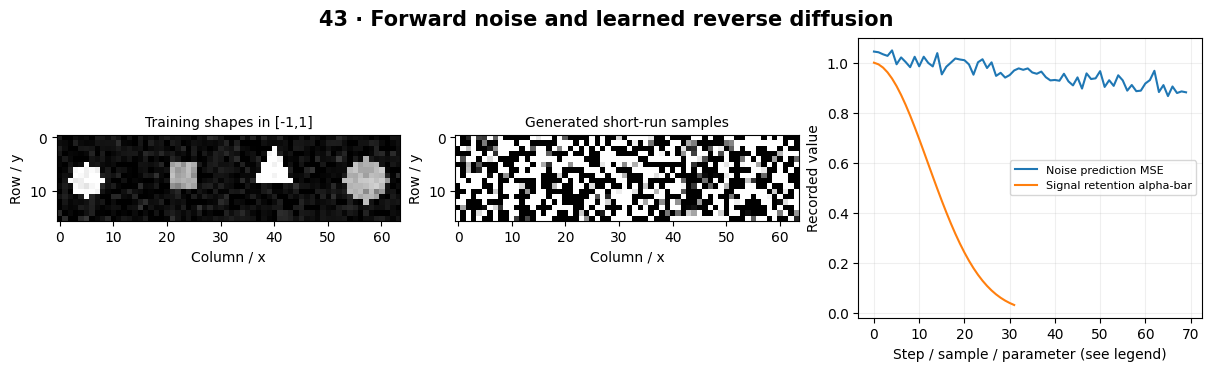

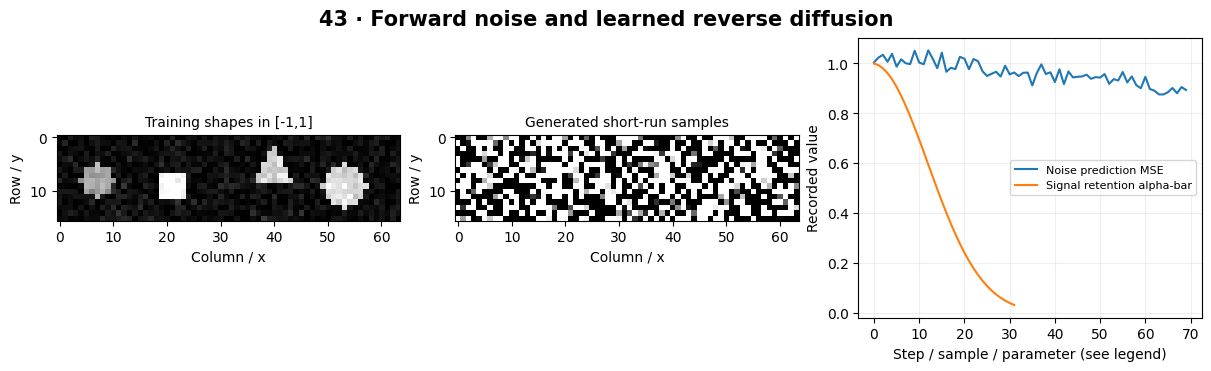

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Tiny Diffusion Experiment**. Explain noise prediction before using a pretrained generator. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Confusing predicted noise with a predicted clean image changes the reverse equation. A falling noise loss is not a guarantee of visually good samples.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Plot signal retention across steps and compare samples after different training budgets. Check that the final forward state is close to the assumed starting distribution.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Implement a conditional shape diffusion model and evaluate whether conditioning changes both class fidelity and sample diversity.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

A noise-prediction network sees the noisy image and time index and predicts the injected noise. Mean squared error supplies a simple training objective. Time conditioning tells the network which noise level it is solving. The local model is a small MLP trained on 16×16 generated shapes.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Reverse sampling and conditioning** in this chapter.

[Primary reference](https://arxiv.org/abs/2006.11239) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)